# CNN Challenge Model 1: ResNet


## 1. Imports & Setup

In [1]:
# Core imports
from pathlib import Path
import random
import time
import copy

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cu130
CUDA available: True


In [2]:
# Import ResNet core
from torchvision.models import resnet18 #shallower variant ResNet18 chosen due to smaller dataset

In [3]:
# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/gdrive')
except ImportError:
    print("Not running in Google Colab; Drive mount skipped.")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [4]:
# Path set to assignment directory

PROJECT_ROOT = Path('/content/gdrive/MyDrive/ITCS_6169/assignment1')
DATA_ROOT = PROJECT_ROOT / 'data'
TRAIN_ROOT = DATA_ROOT / 'train'
TEST_ROOT = DATA_ROOT / 'test'

print('Project root:', PROJECT_ROOT.resolve())
print('Training data:', TRAIN_ROOT)
print('Testing data:', TEST_ROOT)

Project root: /content/gdrive/MyDrive/ITCS_6169/assignment1
Training data: /content/gdrive/MyDrive/ITCS_6169/assignment1/data/train
Testing data: /content/gdrive/MyDrive/ITCS_6169/assignment1/data/test


In [5]:
SEED = 0

def set_random_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_random_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 2. Preprocessing

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 64
VAL_FRACTION = 0.20

resnet_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

full_train_dataset = datasets.ImageFolder(TRAIN_ROOT, transform=resnet_transform)
test_dataset = datasets.ImageFolder(TEST_ROOT, transform=resnet_transform)

class_names = full_train_dataset.classes
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')
print(f'Total training images: {len(full_train_dataset)}')
print(f'Test images: {len(test_dataset)}')

val_size = int(round(len(full_train_dataset) * VAL_FRACTION))
train_size = len(full_train_dataset) - val_size
generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size], generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=torch.cuda.is_available())

print(f'Train: {len(train_dataset)} | Validation: {len(val_dataset)} | Test: {len(test_dataset)}')

Classes (16): ['Bedroom', 'Coast', 'Flower', 'Forest', 'Highway', 'Industrial', 'InsideCity', 'Kitchen', 'LivingRoom', 'Mountain', 'Office', 'OpenCountry', 'Store', 'Street', 'Suburb', 'TallBuilding']
Total training images: 2400
Test images: 400
Train: 1920 | Validation: 480 | Test: 400


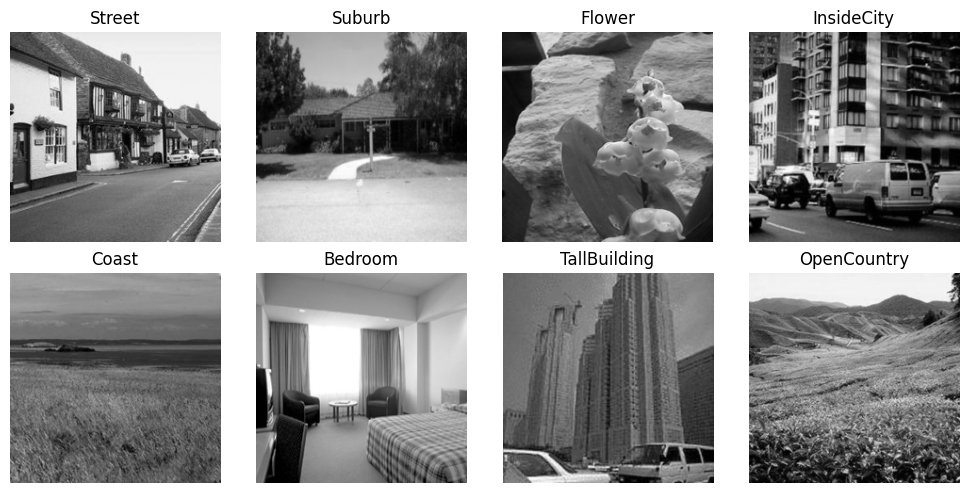

In [7]:
# Visualize a few training examples
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, image, label in zip(axes.flat, images[:8], labels[:8]):
    image = image * 0.5 + 0.5  # unnormalize
    ax.imshow(image.squeeze(0), cmap='gray')
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Training

In [11]:
class ResNet(nn.Module):
    def __init__(self, num_classes=16):
        super().__init__()
        self.model = resnet18(weights=None)

        original_conv1 = self.model.conv1
        self.model.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=original_conv1.out_channels,
            kernel_size=original_conv1.kernel_size,
            stride=original_conv1.stride,
            padding=original_conv1.padding,
            bias=original_conv1.bias is not None
        )

        # Change final fully connected layer to match target number of classes
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.model(x)

## 4. Evaluation

In [12]:
@torch.inference_mode()
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def train_model(model, train_loader, val_loader, optimizer, epochs=20, device=device):
    criterion = nn.CrossEntropyLoss()
    model = model.to(device)
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    start = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_seen = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            total_seen += labels.size(0)

        train_loss = total_loss / total_seen
        val_loss, val_acc = evaluate(model, val_loader, device)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        elapsed = time.time() - start
        print(f'Epoch {epoch:02d}/{epochs} | '
              f'train loss {train_loss:.4f} | val loss {val_loss:.4f} | '
              f'val acc {val_acc:.4f} | {elapsed:.1f}s')

    model.load_state_dict(best_state)
    print(f'Best validation accuracy: {best_val_acc:.4f}')
    return model, history

In [13]:
# Train the ResNet18 model
set_random_seed(SEED)
model = ResNet(num_classes=num_classes)
optimizer = optim.Adam(model.parameters(), lr=0.002)

model, history = train_model(
    model, train_loader, val_loader, optimizer, epochs=20, device=device
)

Epoch 01/20 | train loss 2.3533 | val loss 5.0534 | val acc 0.1542 | 836.7s
Epoch 02/20 | train loss 1.8267 | val loss 2.9133 | val acc 0.2354 | 842.4s
Epoch 03/20 | train loss 1.6531 | val loss 1.9940 | val acc 0.3563 | 848.3s
Epoch 04/20 | train loss 1.4167 | val loss 1.9099 | val acc 0.3833 | 854.0s
Epoch 05/20 | train loss 1.3650 | val loss 2.6008 | val acc 0.3375 | 859.9s
Epoch 06/20 | train loss 1.1270 | val loss 1.1950 | val acc 0.5979 | 865.6s
Epoch 07/20 | train loss 1.0449 | val loss 1.8816 | val acc 0.4396 | 871.4s
Epoch 08/20 | train loss 0.9372 | val loss 1.4522 | val acc 0.5229 | 877.4s
Epoch 09/20 | train loss 0.8020 | val loss 1.4577 | val acc 0.5792 | 883.3s
Epoch 10/20 | train loss 0.7348 | val loss 1.2599 | val acc 0.6312 | 889.1s
Epoch 11/20 | train loss 0.6961 | val loss 1.4445 | val acc 0.5979 | 895.0s
Epoch 12/20 | train loss 0.6461 | val loss 2.4053 | val acc 0.3875 | 900.7s
Epoch 13/20 | train loss 0.5416 | val loss 1.3686 | val acc 0.6125 | 906.4s
Epoch 14/20 

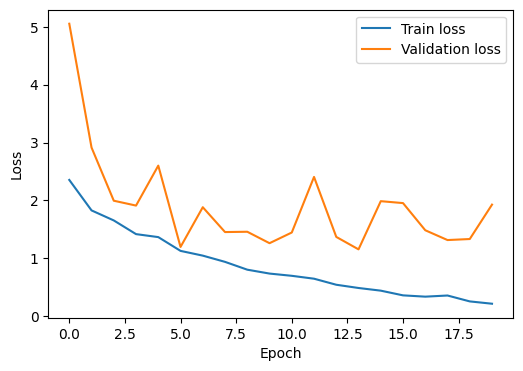

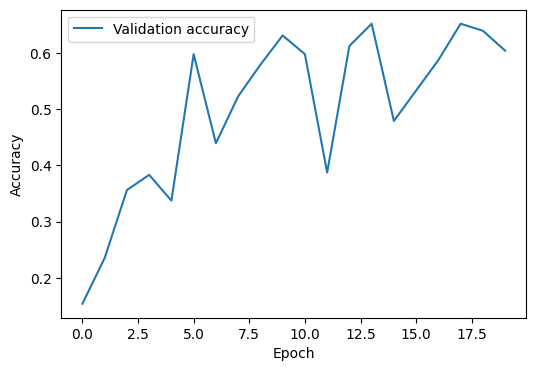

In [14]:
# Plot the starter training history.
plt.figure(figsize=(6, 4))
plt.plot(history['train_loss'], label='Train loss')
plt.plot(history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history['val_acc'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()